In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

_cwd = os.getcwd()
BASE = _cwd if os.path.isdir(os.path.join(_cwd, "src")) else os.path.dirname(_cwd)
CHARTS = os.path.join(BASE, "outputs", "charts")
os.makedirs(CHARTS, exist_ok=True)
print(f"Charts will save to: {CHARTS}")

Charts will save to: /Users/ethan/ethan2026TTU/Housing_Analysis/outputs/charts


In [2]:
df = pd.read_csv(f"{BASE}/data/processed/final_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,RealPrice,HousingStarts,MedianHouseholdIncome,MortgageRate,Population,UnemploymentRate
0,1984-01-01,76591.58,1897,22420.0,13.368,235456,8.0
1,1984-02-01,76218.32,2260,22420.0,13.232,235601,7.8
2,1984-03-01,75996.11,1663,22420.0,13.386,235757,7.8
3,1984-04-01,78121.97,1851,22420.0,13.652,235916,7.7
4,1984-05-01,77971.01,1774,22420.0,13.942,236077,7.4


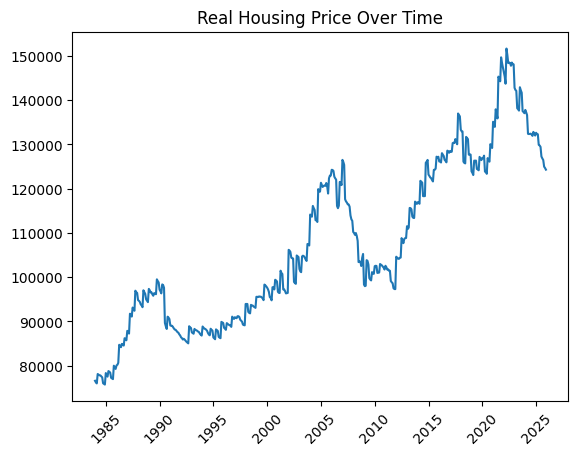

In [3]:
plt.plot(df["Date"], df["RealPrice"])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.title("Real Housing Price Over Time")
plt.savefig(f"{CHARTS}/real_price.png")
plt.show()

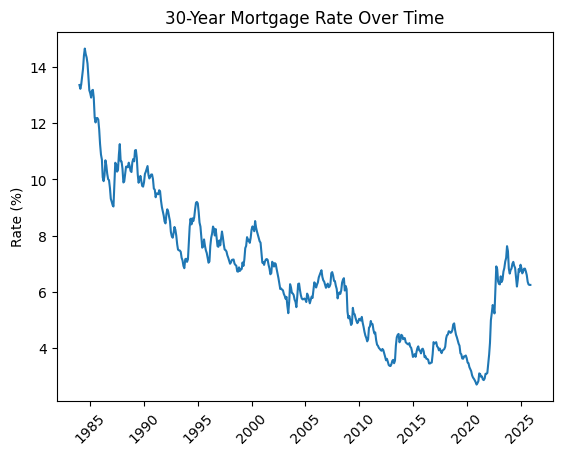

In [4]:
plt.plot(df["Date"], df["MortgageRate"])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.title("30-Year Mortgage Rate Over Time")
plt.ylabel("Rate (%)")
plt.savefig(f"{CHARTS}/mortgage_rate.png")
plt.show()

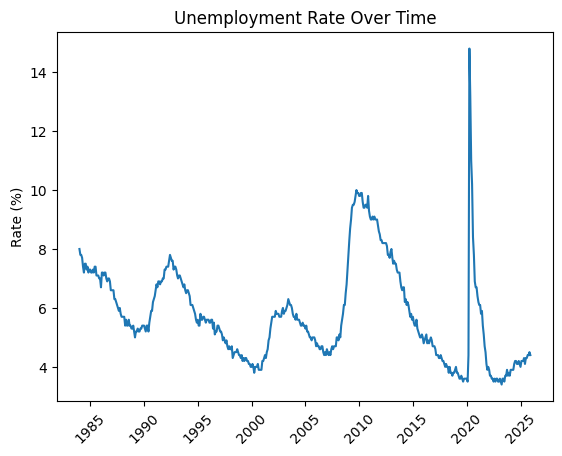

In [5]:
plt.plot(df["Date"], df["UnemploymentRate"])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.title("Unemployment Rate Over Time")
plt.ylabel("Rate (%)")
plt.savefig(f"{CHARTS}/unemployment_rate.png")
plt.show()

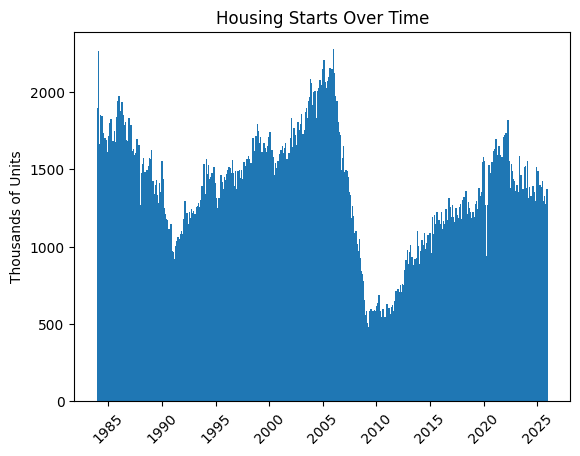

In [6]:
plt.bar(df["Date"], df["HousingStarts"], width=50)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.title("Housing Starts Over Time")
plt.ylabel("Thousands of Units")
plt.savefig(f"{CHARTS}/housing_starts.png")
plt.show()

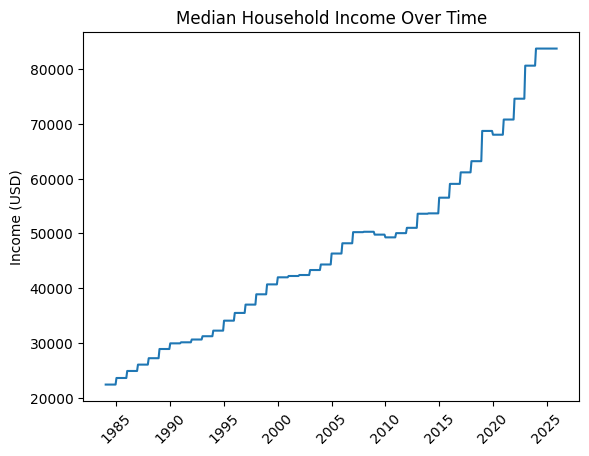

In [7]:
plt.plot(df["Date"], df["MedianHouseholdIncome"])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.title("Median Household Income Over Time")
plt.ylabel("Income (USD)")
plt.savefig(f"{CHARTS}/median_income.png")
plt.show()

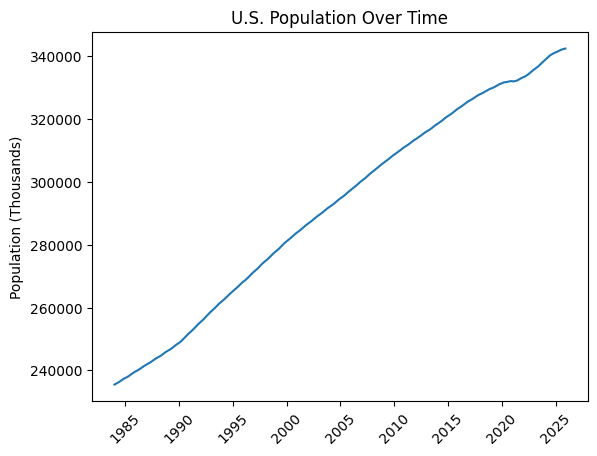

In [8]:
plt.plot(df["Date"], df["Population"])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.title("U.S. Population Over Time")
plt.ylabel("Population (Thousands)")
plt.savefig(f"{CHARTS}/population.png")
plt.show()

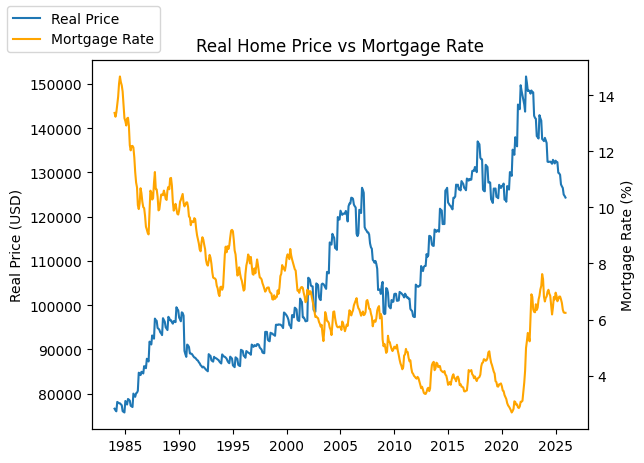

In [9]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(df["Date"], df["RealPrice"], label="Real Price")
ax2.plot(df["Date"], df["MortgageRate"], color="orange", label="Mortgage Rate")
ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax1.set_ylabel("Real Price (USD)")
ax2.set_ylabel("Mortgage Rate (%)")
plt.title("Real Home Price vs Mortgage Rate")
fig.legend(loc="upper left")
plt.savefig(f"{CHARTS}/price_vs_mortgage.png")
plt.show()

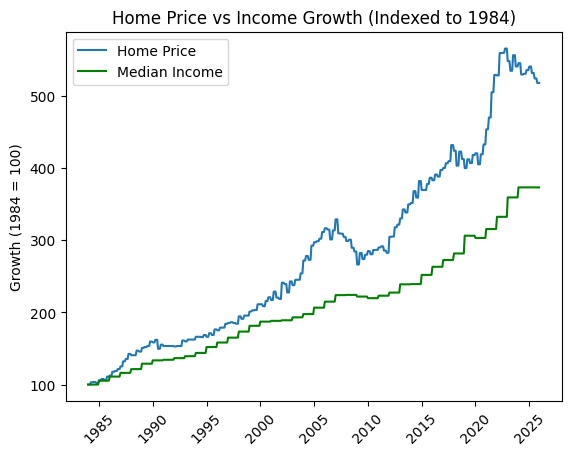

In [10]:
raw = pd.read_csv(f"{BASE}/data/processed/merged_data.csv")
raw["Date"] = pd.to_datetime(raw["Date"])
price_idx  = raw["HomePrice"] / raw["HomePrice"].iloc[0] * 100
income_idx = raw["MedianHouseholdIncome"] / raw["MedianHouseholdIncome"].iloc[0] * 100
plt.plot(raw["Date"], price_idx, label="Home Price")
plt.plot(raw["Date"], income_idx, color="green", label="Median Income")
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.ylabel("Growth (1984 = 100)")
plt.title("Home Price vs Income Growth (Indexed to 1984)")
plt.legend()
plt.savefig(f"{CHARTS}/price_vs_income.png")
plt.show()

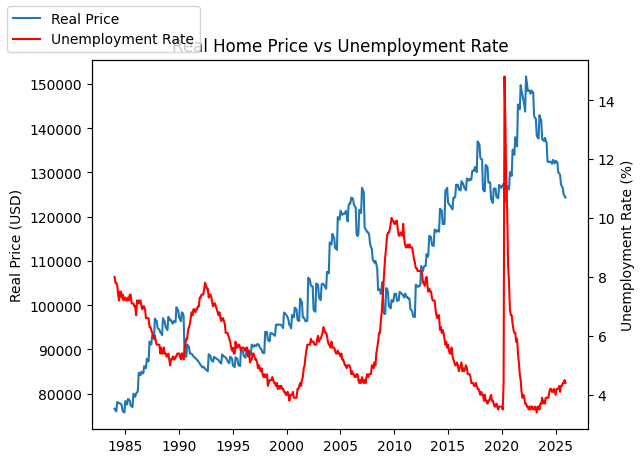

In [11]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(df["Date"], df["RealPrice"], label="Real Price")
ax2.plot(df["Date"], df["UnemploymentRate"], color="red", label="Unemployment Rate")
ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax1.set_ylabel("Real Price (USD)")
ax2.set_ylabel("Unemployment Rate (%)")
plt.title("Real Home Price vs Unemployment Rate")
fig.legend(loc="upper left")
plt.savefig(f"{CHARTS}/price_vs_unemployment.png")
plt.show()

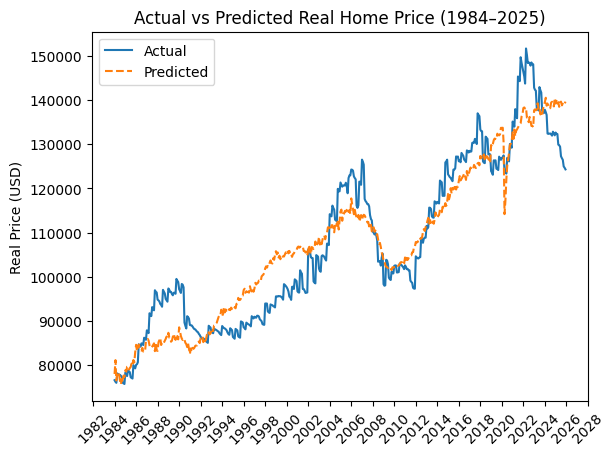

In [12]:
pred = pd.read_csv(f"{BASE}/outputs/regression/predictions.csv")
pred["Date"] = pd.to_datetime(pred["Date"])
plt.plot(pred["Date"], pred["Actual"], label="Actual")
plt.plot(pred["Date"], pred["Predicted"], label="Predicted", linestyle="--")
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.title("Actual vs Predicted Real Home Price (1984–2025)")
plt.ylabel("Real Price (USD)")
plt.legend()
plt.savefig(f"{CHARTS}/actual_vs_predicted.png")
plt.show()

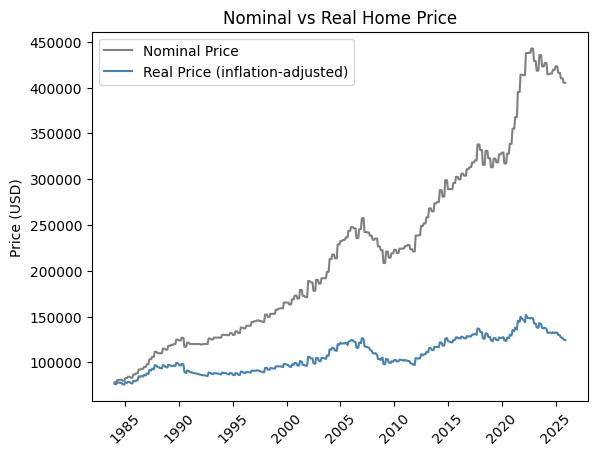

In [13]:
raw = pd.read_csv(f"{BASE}/data/processed/merged_data.csv")
raw["Date"] = pd.to_datetime(raw["Date"])
raw["RealPrice"] = (raw["HomePrice"] / raw["CPI"] * 100).round(2)
plt.plot(raw["Date"], raw["HomePrice"], label="Nominal Price", color="gray")
plt.plot(raw["Date"], raw["RealPrice"], label="Real Price (inflation-adjusted)", color="steelblue")
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.ylabel("Price (USD)")
plt.title("Nominal vs Real Home Price")
plt.legend()
plt.savefig(f"{CHARTS}/nominal_vs_real.png")
plt.show()

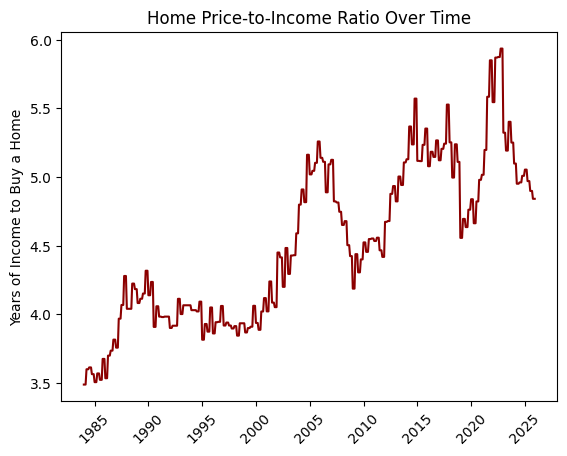

In [14]:
raw["PriceToIncome"] = raw["HomePrice"] / raw["MedianHouseholdIncome"]
plt.plot(raw["Date"], raw["PriceToIncome"], color="darkred")
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.title("Home Price-to-Income Ratio Over Time")
plt.ylabel("Years of Income to Buy a Home")
plt.savefig(f"{CHARTS}/price_to_income_ratio.png")
plt.show()